## Airbnb

Для загрузки данных необходим аккаунт на Kaggle!

Набор данных: [Airbnb price dataset](https://www.kaggle.com/datasets/rupindersinghrana/airbnb-price-dataset)

- Целевая переменная: `log_price` (уже отмасштабирована)
- Зафиксировать `seed=42` при разбиении данных!
- Версия `numpy` должна быть от 1.16 и выше (это скорее всего так, но вдруг кто-то использует старое окружение)
  
  Train и test у всех должны быть одинаковыми! 
  Разбиение данных нужно произвести сразу в первых ячейках ноутбука! (см. код ниже)

Задание:

- Произвести анализ данных (12 занятие в помощь)
- Спроектировать признаки (12 занятие + полная свобода творчества)
- Обучить модель (обязательно ансамбль!)
  - Подобрать гиперпараметры
  - Не забыть про кросс-валидацию
- Рассчитать `RMSE` на тестовой выборке и 95% доверительный интервал
- Прокоменнтировать вышеперечисленные этапы





In [34]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
np.random.seed(42)

In [36]:
df = pd.read_csv('Airbnb_Data.csv')
df

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,...,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,...,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,...,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0
3,13418779,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,...,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,Lower Haight,0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117.0,2.0,2.0
4,3808709,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,...,38.925627,-77.034596,Great studio in midtown DC,Columbia Heights,4,40.0,NaN,20009,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74106,14549287,4.605170,Apartment,Private room,{},1,1.0,Real Bed,flexible,False,...,40.709025,-73.939405,one room bushwick,Williamsburg,0,NaN,https://a0.muscache.com/im/pictures/55162426/6...,11206.0,1.0,1.0
74107,13281809,5.043425,Apartment,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,2.0,Real Bed,moderate,True,...,33.871549,-118.396053,Spacious Hermosa 2 BR on PCH,Hermosa Beach,16,93.0,https://a0.muscache.com/im/pictures/2b86560b-a...,90254,2.0,4.0
74108,18688039,5.220356,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",5,1.0,Real Bed,moderate,True,...,40.706749,-73.942377,Modern 2 Bedroom Apartment in Williamsburg,Williamsburg,43,94.0,https://a0.muscache.com/im/pictures/7fbe448c-5...,11206.0,2.0,2.0
74109,17045948,5.273000,Apartment,Entire home/apt,"{TV,""Wireless Internet"",""Air conditioning"",Kit...",2,1.0,Real Bed,strict,True,...,40.738535,-74.000157,Designer's Apartment in HEART of NYC,West Village,0,NaN,https://a0.muscache.com/im/pictures/b3971b63-0...,10011,0.0,2.0


In [37]:
X = df.drop('log_price', axis=1)
y = df['log_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

У вас должны быть такие же `X_train` и `X_test`:

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74111 entries, 0 to 74110
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      74111 non-null  int64  
 1   log_price               74111 non-null  float64
 2   property_type           74111 non-null  object 
 3   room_type               74111 non-null  object 
 4   amenities               74111 non-null  object 
 5   accommodates            74111 non-null  int64  
 6   bathrooms               73911 non-null  float64
 7   bed_type                74111 non-null  object 
 8   cancellation_policy     74111 non-null  object 
 9   cleaning_fee            74111 non-null  bool   
 10  city                    74111 non-null  object 
 11  description             74111 non-null  object 
 12  first_review            58247 non-null  object 
 13  host_has_profile_pic    73923 non-null  object 
 14  host_identity_verified  73923 non-null

In [43]:
train_df = X_train.copy()
train_df['log_price'] = y_train

train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 59288 entries, 12048 to 15795
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      59288 non-null  int64  
 1   property_type           59288 non-null  object 
 2   room_type               59288 non-null  object 
 3   amenities               59288 non-null  object 
 4   accommodates            59288 non-null  int64  
 5   bathrooms               59128 non-null  float64
 6   bed_type                59288 non-null  object 
 7   cancellation_policy     59288 non-null  object 
 8   cleaning_fee            59288 non-null  bool   
 9   city                    59288 non-null  object 
 10  description             59288 non-null  object 
 11  first_review            46586 non-null  object 
 12  host_has_profile_pic    59128 non-null  object 
 13  host_identity_verified  59128 non-null  object 
 14  host_response_rate      44647 non-null 

In [45]:
train_df.describe()

,id,accommodates,bathrooms,latitude,longitude,number_of_reviews,review_scores_rating,bedrooms,beds,log_price
count,5.928800e+04,59288.000000,59128.000000,59288.000000,59288.000000,59288.000000,45893.000000,59210.000000,59184.000000,59288.000000
mean,1.126102e+07,3.152054,1.236183,38.450807,-92.349408,20.935805,94.076526,1.265817,1.712862,4.780538
std,6.087273e+06,2.153512,0.582392,3.080455,21.688276,37.950408,7.807910,0.849750,1.259406,0.717547
min,9.410000e+02,1.000000,0.000000,33.338905,-122.511500,0.000000,20.000000,0.000000,0.000000,0.000000
25%,6.245493e+06,2.000000,1.000000,34.128782,-118.341975,1.000000,92.000000,1.000000,1.000000,4.304065
50%,1.224695e+07,2.000000,1.000000,40.663197,-76.995645,6.000000,96.000000,1.000000,1.000000,4.700480
75%,1.640730e+07,4.000000,1.000000,40.746167,-73.954621,23.000000,100.000000,1.000000,2.000000,5.220356
max,2.123090e+07,16.000000,8.000000,42.390437,-70.999166,605.000000,100.000000,10.000000,18.000000,7.600402


In [47]:
df['room_type'].value_counts()

room_type
Entire home/apt    41310
Private room       30638
Shared room         2163
Name: count, dtype: int64

In [49]:
missing = train_df.isnull().sum()
missing_pct = (missing / len(train_df) * 100).round(2)

missing_info = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).query('missing_count > 0').sort_values('missing_pct', ascending=False)
print(missing_info)

                        missing_count  missing_pct
host_response_rate              14641        24.69
review_scores_rating            13395        22.59
first_review                    12702        21.42
last_review                     12672        21.37
thumbnail_url                    6587        11.11
neighbourhood                    5509         9.29
zipcode                           761         1.28
bathrooms                         160         0.27
host_has_profile_pic              160         0.27
host_identity_verified            160         0.27
host_since                        160         0.27
beds                              104         0.18
bedrooms                           78         0.13


In [51]:
Отдельная обработка для числовых и текстовых данных!

SyntaxError: invalid syntax (1473444937.py, line 1)

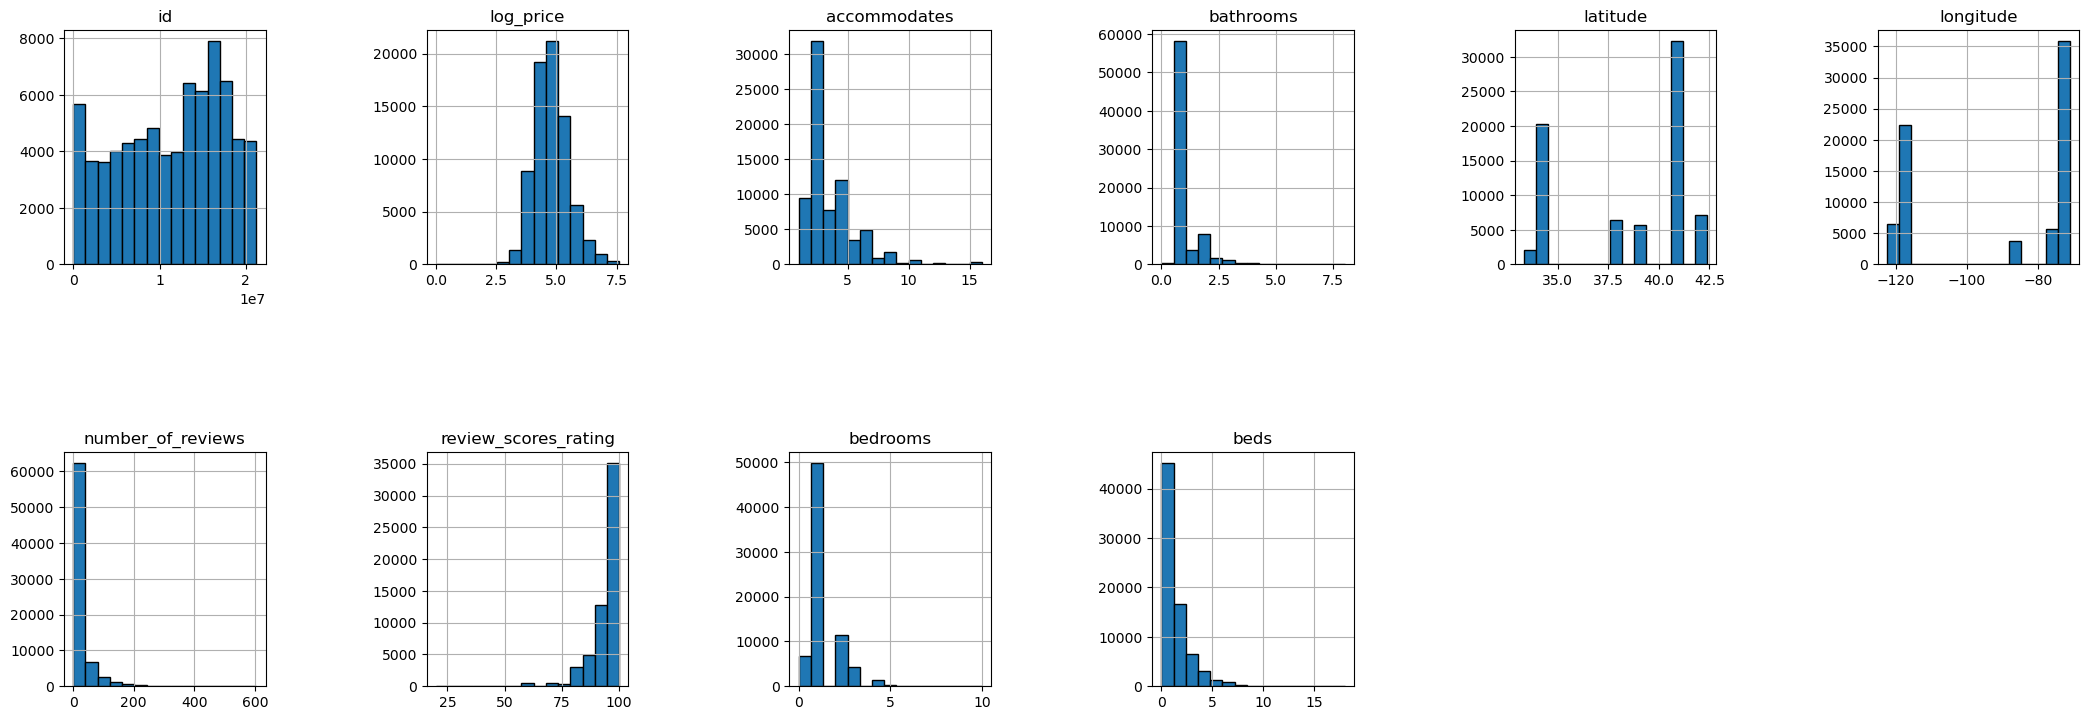

In [53]:
numerical_data = df.select_dtypes(include="number")
numerical_data.hist(
    bins=15, figsize=(26, 14), edgecolor="black", layout=(3, 6)
)
plt.subplots_adjust(hspace=0.8, wspace=0.8)

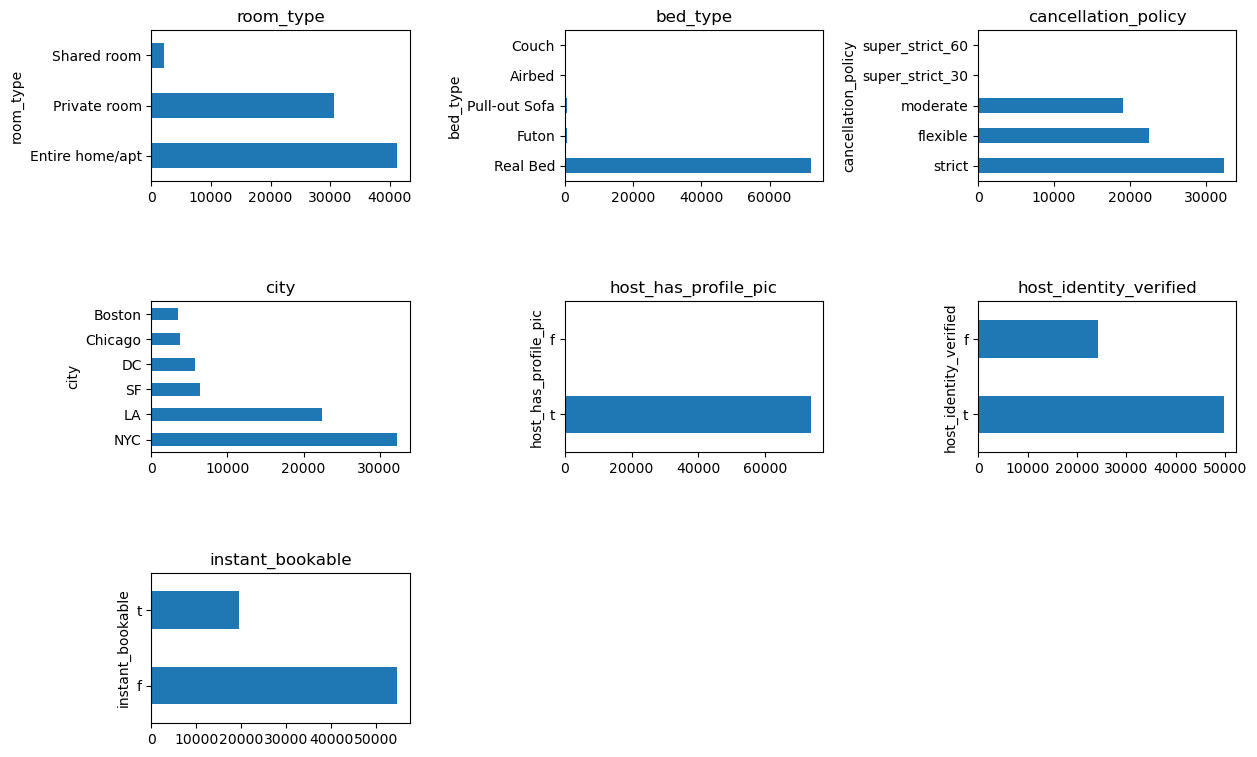

In [55]:
from math import ceil
from itertools import zip_longest


string_data = df.select_dtypes(object)

cat_cols_to_plot = [c for c in string_data.columns if df[c].nunique() <= 20]

n_string_features = len(cat_cols_to_plot)
nrows, ncols = ceil(n_string_features / 3), 3

fig, axs = plt.subplots(ncols=ncols, nrows=nrows, figsize=(14, nrows * 3))

for feature_name, ax in zip_longest(cat_cols_to_plot, axs.ravel()):
    if feature_name is None:
        ax.axis("off")
        continue
    string_data[feature_name].value_counts().plot.barh(ax=ax)
    ax.set_title(feature_name)

plt.subplots_adjust(hspace=0.8, wspace=0.6)

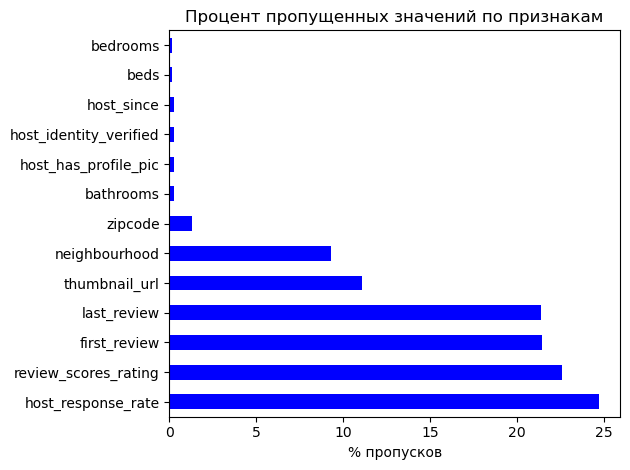

In [56]:
missing_info['missing_pct'].plot(kind='barh', color='blue')
plt.title('Процент пропущенных значений по признакам')
plt.xlabel('% пропусков')
plt.tight_layout()
plt.show()

In [58]:

X = df.drop('log_price', axis=1)
y = df['log_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(len(X_train))
print(len(X_test))

59288
14823


In [61]:
X_train

,id,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
12048,760827,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",""A...",4,1.5,Real Bed,flexible,False,LA,...,34.109039,-118.273390,Comfortable guesthouse in Los Feliz,Los Feliz,12,97.0,https://a0.muscache.com/im/pictures/68126735/8...,90027,2.0,3.0
48255,3257345,Apartment,Entire home/apt,"{TV,""Wireless Internet"",Kitchen,""Free parking ...",2,1.0,Real Bed,strict,True,NYC,...,40.812897,-73.919163,Garden apartment w/ parking! Colorful Cheery S...,Mott Haven,6,87.0,https://a0.muscache.com/im/pictures/de651e45-a...,10454,1.0,1.0
39959,13355012,Apartment,Entire home/apt,"{TV,""Air conditioning"",Kitchen,Heating,""Smoke ...",4,1.0,Real Bed,strict,True,NYC,...,40.737643,-73.953309,Greenpoint Studio w/ KING bed and Sofabed!,Greenpoint,4,80.0,https://a0.muscache.com/im/pictures/02fe96c0-8...,11222,0.0,2.0
14926,4565981,Apartment,Private room,{},2,1.0,Real Bed,flexible,True,SF,...,37.759935,-122.420558,Comfy Valenica Street bedroom,Mission District,0,NaN,https://a0.muscache.com/im/pictures/03292fda-2...,94110,1.0,1.0
776,6940108,Apartment,Entire home/apt,"{Internet,""Wireless Internet"",""Air conditionin...",3,1.0,Real Bed,moderate,True,NYC,...,40.683363,-73.949490,charming brooklyn apartment,Bedford-Stuyvesant,16,99.0,NaN,11216,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37194,15101498,Apartment,Private room,"{TV,""Wireless Internet"",""Air conditioning"",Kit...",2,1.5,Real Bed,strict,True,LA,...,34.094867,-118.292013,"✿ܓBEAUTFL PRIV #4+PRIVATE 1/2 BA, SHARED FULL ...",East Hollywood,1,100.0,https://a0.muscache.com/im/pictures/7d28c5b1-8...,90029,1.0,1.0
6265,298258,House,Private room,"{TV,Internet,""Wireless Internet"",""Air conditio...",1,1.0,Real Bed,flexible,True,LA,...,34.150509,-118.787469,Lovely room with a view,NaN,2,90.0,https://a0.muscache.com/im/pictures/72186809/2...,91301,1.0,1.0
54886,4917508,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",""A...",5,2.0,Real Bed,strict,True,LA,...,34.087073,-118.336914,Amazing 2 bed & 2 bath Melrose dist,Hollywood,20,91.0,https://a0.muscache.com/im/pictures/22515d38-5...,90038,2.0,2.0
860,16645828,Apartment,Private room,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,strict,True,NYC,...,40.771579,-73.957856,Prime location private room in furnished ap 3b...,Upper East Side,0,NaN,NaN,10021,1.0,1.0


In [63]:
X_test

,id,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
4079,13662370,House,Private room,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.5,Real Bed,strict,True,Chicago,...,41.849684,-87.676270,Pilsen Arts Community Custom Home,Pilsen,17,97.0,https://a0.muscache.com/im/pictures/81318153/a...,60608,1.0,1.0
33735,4765892,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,2.0,Real Bed,strict,True,LA,...,34.068613,-118.246455,Apartment 5 minutes from DTLA & Dodger Stadium,Echo Park,2,100.0,https://a0.muscache.com/im/pictures/aa00250e-0...,90012,1.0,1.0
69475,21169968,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,NYC,...,40.701958,-73.917352,"Brand New Huge 2bdr apartment(L,M train 2 min)",Bushwick,25,88.0,https://a0.muscache.com/im/pictures/d9220535-c...,11237,2.0,3.0
454,7939196,Apartment,Entire home/apt,"{""Cable TV"",Internet,""Wireless Internet"",""Air ...",6,1.0,Real Bed,strict,True,NYC,...,40.742959,-73.990820,Grande Super Large APT !!!,Flatiron District,12,82.0,NaN,10010,1.0,3.0
25153,18161036,House,Private room,"{Internet,""Wireless Internet"",""Air conditionin...",2,1.0,Real Bed,flexible,True,LA,...,34.046473,-117.734095,Private Cozy and Clean Rooms in Pomona,NaN,2,100.0,https://a0.muscache.com/im/pictures/e0c9b2f9-a...,91766,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4775,9759707,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",4,1.0,Real Bed,strict,True,NYC,...,40.764226,-73.976932,Cozy & Quiet 1 Bedroom - 1 block from central ...,Midtown,5,100.0,https://a0.muscache.com/im/pictures/29cbf250-7...,10019,1.0,2.0
14723,17703848,House,Private room,"{TV,Internet,""Wireless Internet"",""Air conditio...",4,1.0,Real Bed,moderate,True,LA,...,34.134544,-118.360631,King & 2 Twin beds- Walk to UNIVERSAL,NaN,41,89.0,https://a0.muscache.com/im/pictures/fbf3e8ab-c...,90068,1.0,2.0
29953,17319362,Apartment,Entire home/apt,"{Kitchen,Heating,""Family/kid friendly"",Washer,...",2,1.0,Real Bed,moderate,True,NYC,...,40.649617,-74.003502,Sunny and pleasant Sunset Park apt,Sunset Park,0,NaN,https://a0.muscache.com/im/pictures/111568106/...,11232,1.0,1.0
38582,19403704,House,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",10,1.5,Real Bed,strict,True,LA,...,34.075903,-118.254904,Location + Comfort + Cleanliness = Paradise,Echo Park,38,91.0,NaN,90026,3.0,3.0


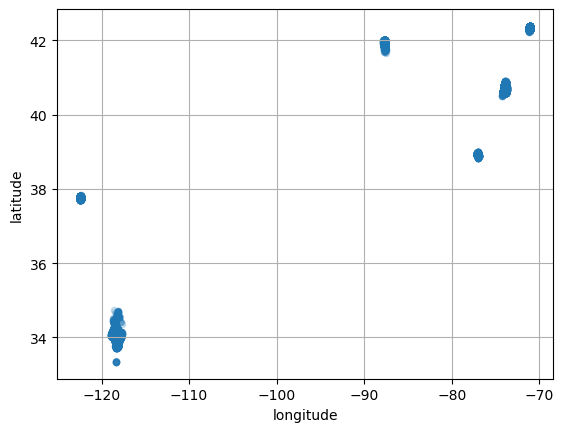

In [65]:
train_set = X_train.copy()
train_set['log_price'] = y_train.values

train_set.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2)
plt.show()

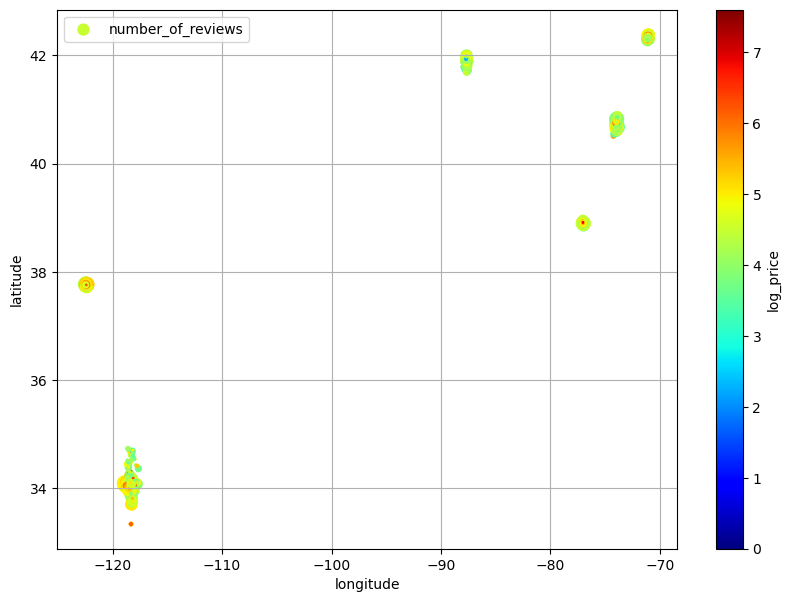

In [67]:
train_set.plot(
    kind="scatter", x="longitude", y="latitude", grid=True,
    s=train_set["number_of_reviews"] / 5 + 1, label="number_of_reviews",
    c="log_price", cmap="jet", colorbar=True,
    legend=True, sharex=False, figsize=(10, 7)
)
plt.show()

Поиск корреляций

Стандартный коэффициент корреляции $\rho$ между каждой парой атрибутов (метод `corr()`).

In [70]:
corr_matrix = train_set.select_dtypes(include="number").corr()
corr_matrix["log_price"].sort_values(ascending=False)

log_price               1.000000
accommodates            0.569175
bedrooms                0.475462
beds                    0.443746
bathrooms               0.352129
review_scores_rating    0.092239
latitude                0.000427
id                     -0.007145
number_of_reviews      -0.030763
longitude              -0.045283
Name: log_price, dtype: float64

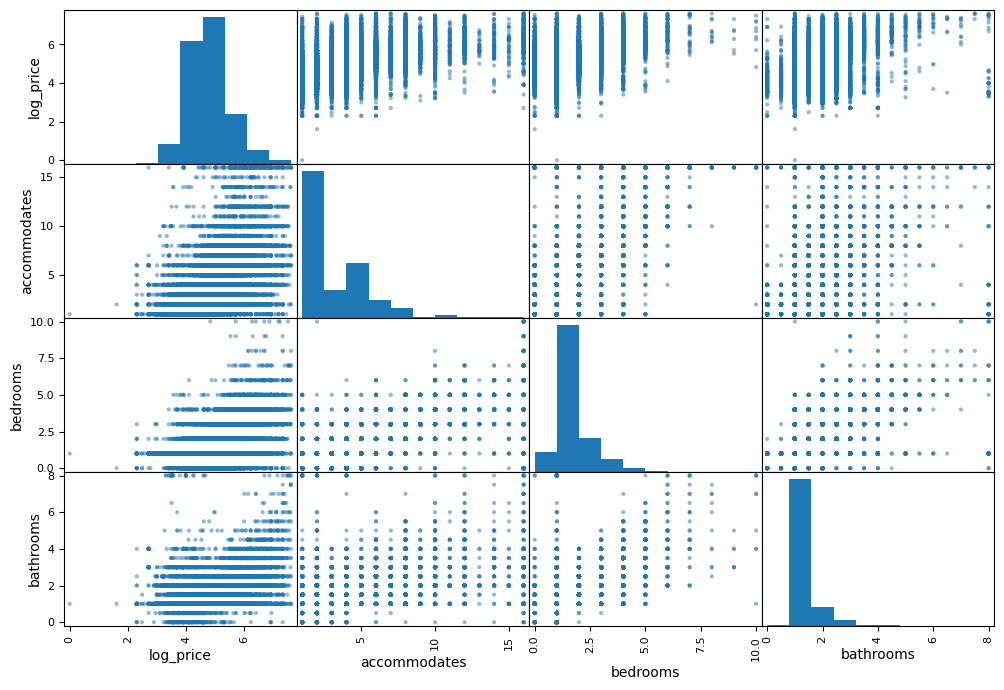

In [72]:
attributes = ["log_price", "accommodates", "bedrooms", "bathrooms"]
pd.plotting.scatter_matrix(train_set[attributes], figsize=(12, 8))
plt.show()

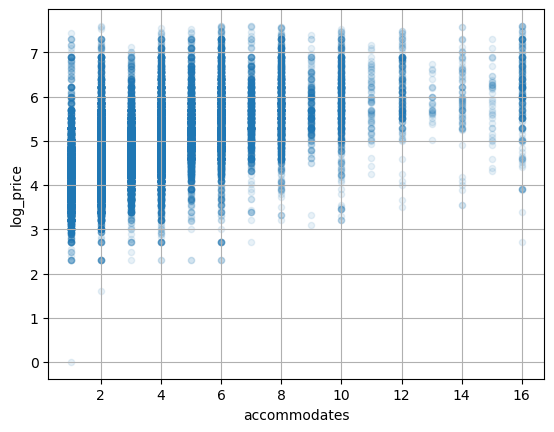

In [73]:
train_set.plot(
    kind="scatter", x="accommodates", y="log_price", alpha=0.1, grid=True)
plt.show()

In [74]:
train_set["beds_per_person"]     = train_set["beds"] / train_set["accommodates"]
train_set["bath_per_person"]     = train_set["bathrooms"] / train_set["accommodates"]
train_set["bedrooms_per_person"] = train_set["bedrooms"] / train_set["accommodates"]

corr_matrix = train_set.select_dtypes(include="number").corr()
corr_matrix["log_price"].sort_values(ascending=False)

log_price               1.000000
accommodates            0.569175
bedrooms                0.475462
beds                    0.443746
bathrooms               0.352129
review_scores_rating    0.092239
latitude                0.000427
id                     -0.007145
number_of_reviews      -0.030763
longitude              -0.045283
beds_per_person        -0.213946
bedrooms_per_person    -0.263945
bath_per_person        -0.372533
Name: log_price, dtype: float64

In [75]:
drop_cols = ['id', 'name', 'description', 'thumbnail_url', 'neighbourhood', 'zipcode']
drop_cols = [c for c in drop_cols if c in X_train.columns]

housing = X_train.drop(drop_cols, axis=1)
housing_labels = y_train.copy()

In [76]:
null_rows_idx = housing.isnull().any(axis=1)
housing.loc[null_rows_idx].head()

,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,first_review,...,host_response_rate,host_since,instant_bookable,last_review,latitude,longitude,number_of_reviews,review_scores_rating,bedrooms,beds
12048,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",""A...",4,1.5,Real Bed,flexible,False,LA,2015-05-07,...,NaN,2015-02-25,f,2016-06-26,34.109039,-118.273390,12,97.0,2.0,3.0
48255,Apartment,Entire home/apt,"{TV,""Wireless Internet"",Kitchen,""Free parking ...",2,1.0,Real Bed,strict,True,NYC,2016-07-02,...,NaN,2009-10-27,t,2016-07-31,40.812897,-73.919163,6,87.0,1.0,1.0
14926,Apartment,Private room,{},2,1.0,Real Bed,flexible,True,SF,NaN,...,NaN,2013-03-19,f,NaN,37.759935,-122.420558,0,NaN,1.0,1.0
53709,Apartment,Entire home/apt,"{TV,""Wireless Internet"",""Air conditioning"",Kit...",5,1.0,Real Bed,flexible,True,NYC,2016-11-08,...,NaN,2014-08-25,t,2017-07-02,40.714336,-73.960847,4,100.0,3.0,2.0
20768,Apartment,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",""A...",1,1.0,Real Bed,flexible,False,NYC,2016-05-31,...,NaN,2016-03-16,f,2016-10-23,40.772482,-73.981084,3,100.0,1.0,1.0


In [78]:

imputer = SimpleImputer(strategy="median")
housing_num = housing.select_dtypes(include=[np.number])
imputer.fit(housing_num)

print(imputer.statistics_)
print(housing_num.median().values)

[  2.           1.          40.66319724 -76.99564545   6.
  96.           1.           1.        ]
[  2.           1.          40.66319724 -76.99564545   6.
  96.           1.           1.        ]


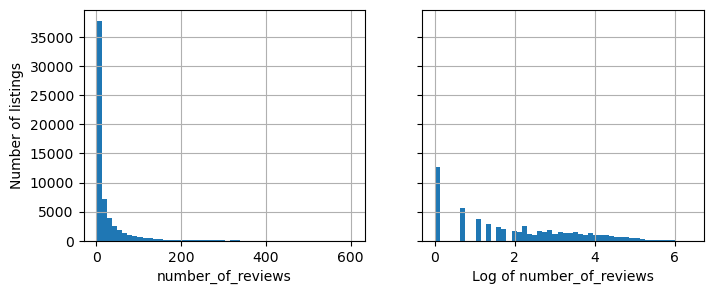

In [82]:
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
housing["number_of_reviews"].hist(ax=axs[0], bins=50)
housing["number_of_reviews"].apply(np.log1p).hist(ax=axs[1], bins=50)
axs[0].set_xlabel("number_of_reviews")
axs[1].set_xlabel("Log of number_of_reviews")
axs[0].set_ylabel("Number of listings")
plt.show()

In [86]:
from sklearn.preprocessing import StandardScaler


target_scaler = StandardScaler()
scaled_labels = target_scaler.fit_transform(housing_labels.to_frame())

In [88]:
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder

In [90]:
def add_features(df):
    """Добавляем новые признаки и приводим данные к числовому виду."""
    df = df.copy()

    df["beds_per_person"]     = df["beds"] / df["accommodates"].clip(lower=1)
    df["bath_per_person"]     = df["bathrooms"] / df["accommodates"].clip(lower=1)
    df["bedrooms_per_person"] = df["bedrooms"] / df["accommodates"].clip(lower=1)

    # Количество удобств
    if "amenities" in df.columns:
        df["amenities_count"] = df["amenities"].apply(
            lambda s: len(str(s).strip("{}").split(",")) if pd.notna(s) else 0
        )
        df.drop("amenities", axis=1, inplace=True)

    bool_map = {"t": 1, "f": 0, "True": 1, "False": 0}
    for col in ["host_has_profile_pic", "host_identity_verified",
                "instant_bookable", "cleaning_fee"]:
        if col in df.columns:
            df[col] = df[col].map(bool_map).fillna(0).astype(int)

    if "host_response_rate" in df.columns:
        df["host_response_rate"] = (
            df["host_response_rate"]
            .astype(str)
            .str.replace("%", "", regex=False)
            .pipe(pd.to_numeric, errors="coerce")
            / 100.0
        )

    ref_date = pd.Timestamp("2018-01-01")
    for col in ["host_since", "first_review", "last_review"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")
            df[col + "_days"] = (ref_date - df[col]).dt.days.clip(lower=0)
            df.drop(col, axis=1, inplace=True)

    return df


housing_fe = add_features(housing)
housing_fe.head()

,property_type,room_type,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,host_has_profile_pic,host_identity_verified,...,review_scores_rating,bedrooms,beds,beds_per_person,bath_per_person,bedrooms_per_person,amenities_count,host_since_days,first_review_days,last_review_days
12048,House,Entire home/apt,4,1.5,Real Bed,flexible,0,LA,1,1,...,97.0,2.0,3.0,0.750000,0.375000,0.500000,17,1041.0,970.0,554.0
48255,Apartment,Entire home/apt,2,1.0,Real Bed,strict,0,NYC,1,1,...,87.0,1.0,1.0,0.500000,0.500000,0.500000,18,2988.0,548.0,519.0
39959,Apartment,Entire home/apt,4,1.0,Real Bed,strict,0,NYC,1,0,...,80.0,0.0,2.0,0.500000,0.250000,0.000000,11,186.0,184.0,154.0
14926,Apartment,Private room,2,1.0,Real Bed,flexible,0,SF,1,1,...,NaN,1.0,1.0,0.500000,0.500000,0.500000,1,1749.0,NaN,NaN
776,Apartment,Entire home/apt,3,1.0,Real Bed,moderate,0,NYC,1,1,...,99.0,1.0,1.0,0.333333,0.333333,0.333333,13,2347.0,1342.0,589.0


In [92]:
# Проверка корреляцию новых признаков с целевой переменной
housing_fe_with_target = housing_fe.copy()
housing_fe_with_target["log_price"] = housing_labels.values

corr_matrix = housing_fe_with_target.select_dtypes(include="number").corr()
corr_matrix["log_price"].sort_values(ascending=False)

log_price                 1.000000
accommodates              0.569175
bedrooms                  0.475462
beds                      0.443746
bathrooms                 0.352129
amenities_count           0.197263
review_scores_rating      0.092239
first_review_days         0.082192
host_since_days           0.079019
host_identity_verified    0.026604
last_review_days          0.021362
latitude                  0.000427
host_response_rate       -0.004896
host_has_profile_pic     -0.010360
number_of_reviews        -0.030763
instant_bookable         -0.044056
longitude                -0.045283
beds_per_person          -0.213946
bedrooms_per_person      -0.263945
bath_per_person          -0.372533
cleaning_fee                   NaN
Name: log_price, dtype: float64

In [94]:
def column_ratio(X):
    return X[:, [0]] / X[:, [1]]


def ratio_pipeline(name=None):
    return make_pipeline(
        SimpleImputer(strategy="median"),
        FunctionTransformer(column_ratio, feature_names_out=lambda _, input_features: [name]),
        StandardScaler()
    )


log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log1p, feature_names_out="one-to-one"),
    StandardScaler()
)

default_num_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
)

cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore")
)

# Признаки с тяжёлым хвостом, значит логарифмируем
log_features = ["number_of_reviews"]
log_features = [c for c in log_features if c in housing_fe.columns]

num_features = housing_fe.select_dtypes(include="number").columns.tolist()
num_features = [c for c in num_features if c not in log_features]
num_features = [c for c in num_features if c not in ["beds_per_person", "bath_per_person", "bedrooms_per_person"]]

preprocessing = ColumnTransformer([
    ("beds_per_person",     ratio_pipeline("beds_per_person"),     ["beds", "accommodates"]),
    ("bath_per_person",     ratio_pipeline("bath_per_person"),     ["bathrooms", "accommodates"]),
    ("bedrooms_per_person", ratio_pipeline("bedrooms_per_person"), ["bedrooms", "accommodates"]),
    ("log",  log_pipeline,         log_features),
    ("num",  default_num_pipeline, num_features),
    ("cat",  cat_pipeline,         make_column_selector(dtype_include=object)),
])

In [112]:
housing_prepared = preprocessing.fit_transform(housing_fe)
housing_prepared.shape

(59288, 73)

In [110]:
preprocessing.get_feature_names_out()

array(['beds_per_person__beds_per_person',
       'bath_per_person__bath_per_person',
       'bedrooms_per_person__bedrooms_per_person',
       'log__number_of_reviews', 'num__accommodates', 'num__bathrooms',
       'num__cleaning_fee', 'num__host_has_profile_pic',
       'num__host_identity_verified', 'num__host_response_rate',
       'num__instant_bookable', 'num__latitude', 'num__longitude',
       'num__review_scores_rating', 'num__bedrooms', 'num__beds',
       'num__amenities_count', 'num__host_since_days',
       'num__first_review_days', 'num__last_review_days',
       'cat__property_type_Apartment',
       'cat__property_type_Bed & Breakfast', 'cat__property_type_Boat',
       'cat__property_type_Boutique hotel', 'cat__property_type_Bungalow',
       'cat__property_type_Cabin', 'cat__property_type_Camper/RV',
       'cat__property_type_Casa particular', 'cat__property_type_Castle',
       'cat__property_type_Cave', 'cat__property_type_Chalet',
       'cat__property_type_Condom

In [121]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error

sample_size = 10000
indices = np.random.choice(len(housing_prepared), sample_size, replace=False)
housing_small = housing_prepared[indices]
labels_small = scaled_labels.ravel()[indices]

forest_reg = RandomForestRegressor(n_estimators=10, random_state=42)  # всего 10 деревьев
forest_rmses = -cross_val_score(forest_reg, housing_small, labels_small,
                                scoring="neg_root_mean_squared_error", cv=3)  # 3 фолда

In [123]:
pd.Series(forest_rmses).describe()

count    3.000000
mean     0.614657
std      0.007628
min      0.608218
25%      0.610445
50%      0.612671
75%      0.617876
max      0.623081
dtype: float64

In [135]:
sample_frac = 0.3
np.random.seed(42)
indices = np.random.choice(len(housing_fe), int(len(housing_fe) * sample_frac), replace=False)
X_sample = housing_fe.iloc[indices]
y_sample = scaled_labels[indices].ravel()

In [137]:
from sklearn.model_selection import GridSearchCV

# Упрощённая сетка (чтобы быстро считалось)
param_grid = {
    "random_forest__max_features": [6, 8],
    "random_forest__n_estimators": [50, 100],
    "random_forest__max_depth": [None, 20]
}

grid_search = GridSearchCV(
    full_pipeline, param_grid,
    cv=3, scoring="neg_root_mean_squared_error",
    verbose=1, n_jobs=-1
)

# Обучаем на ВЫБОРКЕ (быстро)
grid_search.fit(X_sample, y_sample)

print("Лучшие параметры GridSearchCV:", grid_search.best_params_)
best_rmse_scaled = -grid_search.best_score_
best_rmse_orig = best_rmse_scaled * target_scaler.scale_[0]
print(f"Лучший RMSE (исходный log_price): {best_rmse_orig:.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Лучшие параметры GridSearchCV: {'random_forest__max_depth': None, 'random_forest__max_features': 8, 'random_forest__n_estimators': 100}
Лучший RMSE (исходный log_price): 0.4197


In [139]:

if hasattr(grid_search, 'cv_results_'):
    cv_res = pd.DataFrame(grid_search.cv_results_)
    cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)

    cv_res = cv_res[[
        "param_random_forest__max_features",
        "param_random_forest__n_estimators",
        "split0_test_score", "split1_test_score",
        "split2_test_score", "mean_test_score"
    ]]

    score_cols = ["split0", "split1", "split2", "mean_test_rmse"]
    cv_res.columns = ["max_features", "n_estimators"] + score_cols
    cv_res[score_cols] = (-cv_res[score_cols] * target_scaler.scale_[0]).round(4)
    print(cv_res.head())
else:
    print("GridSearchCV не был обучен. Пропускаем таблицу.")

   max_features  n_estimators  split0  split1  split2  mean_test_rmse
3             8           100  0.4241  0.4173  0.4176          0.4197
7             8           100  0.4249  0.4187  0.4203          0.4213
2             8            50  0.4254  0.4205  0.4186          0.4215
1             6           100  0.4272  0.4214  0.4205          0.4230
6             8            50  0.4275  0.4213  0.4215          0.4234


In [141]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distribs = {
    "random_forest__max_features": randint(4, 12),
    "random_forest__n_estimators": randint(30, 100),
    "random_forest__max_depth": [None, 10, 20]
}

rnd_search = RandomizedSearchCV(
    full_pipeline,
    param_distributions=param_distribs,
    n_iter=10,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    verbose=1,
    n_jobs=-1
)

rnd_search.fit(X_sample, y_sample)

print("Лучшие параметры RandomizedSearchCV:", rnd_search.best_params_)
best_rmse_scaled = -rnd_search.best_score_
best_rmse_orig = best_rmse_scaled * target_scaler.scale_[0]
print(f"Лучший RMSE (исходный log_price): {best_rmse_orig:.4f}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Лучшие параметры RandomizedSearchCV: {'random_forest__max_depth': 20, 'random_forest__max_features': 11, 'random_forest__n_estimators': 90}
Лучший RMSE (исходный log_price): 0.4173


In [143]:
if hasattr(rnd_search, 'cv_results_'):
    cv_res = pd.DataFrame(rnd_search.cv_results_)
    cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)

    cv_res = cv_res[[
        "param_random_forest__max_features",
        "param_random_forest__n_estimators",
        "split0_test_score", "split1_test_score",
        "split2_test_score", "mean_test_score"
    ]]

    score_cols = ["split0", "split1", "split2", "mean_test_rmse"]
    cv_res.columns = ["max_features", "n_estimators"] + score_cols
    cv_res[score_cols] = (-cv_res[score_cols] * target_scaler.scale_[0]).round(4)
    print(cv_res.head())
else:
    print("RandomizedSearchCV не был обучен.")

   max_features  n_estimators  split0  split1  split2  mean_test_rmse
1            11            90  0.4221  0.4146  0.4151          0.4173
2            10            53  0.4234  0.4167  0.4181          0.4194
9             9            91  0.4256  0.4166  0.4162          0.4194
3             9            82  0.4255  0.4169  0.4160          0.4194
8             6            71  0.4293  0.4230  0.4237          0.4253


In [145]:

final_model = rnd_search.best_estimator_

feature_importances = final_model["random_forest"].feature_importances_

print("Важности признаков получены.")

Важности признаков получены.


In [147]:

feature_names = final_model["preprocessing"].get_feature_names_out()

sorted_importances = sorted(zip(feature_importances, feature_names), reverse=True)

print("\n=== Важность признаков (топ-10) ===")
for imp, name in sorted_importances[:10]:
    print(f"{name}: {imp:.4f}")


=== Важность признаков (топ-10) ===
cat__room_type_Entire home/apt: 0.1469
num__bedrooms: 0.0864
num__longitude: 0.0760
cat__room_type_Private room: 0.0713
num__accommodates: 0.0686
num__latitude: 0.0618
num__bathrooms: 0.0602
bath_per_person__bath_per_person: 0.0539
num__beds: 0.0417
num__host_since_days: 0.0369


In [149]:
from sklearn.metrics import root_mean_squared_error

# Подготовка тестовых данных (удаляем лишние колонки и добавляем признаки)
X_test_fe = add_features(
    X_test.drop([c for c in drop_cols if c in X_test.columns], axis=1)
)

final_predictions_scaled = final_model.predict(X_test_fe)


final_predictions = target_scaler.inverse_transform(
    final_predictions_scaled.reshape(-1, 1)
).ravel()

# Расчёт RMSE
final_rmse = root_mean_squared_error(y_test, final_predictions)
print(f"\n=== Финальный RMSE на тесте ===")
print(f"RMSE (в исходном масштабе log_price): {final_rmse:.4f}")


=== Финальный RMSE на тесте ===
RMSE (в исходном масштабе log_price): 0.4129


In [153]:
from sklearn.utils import resample
import numpy as np

squared_errors = (final_predictions - y_test) ** 2
n_boot = 1000
boot_rmse = []

for _ in range(n_boot):
    sample = resample(squared_errors, random_state=42)   # используем целое число
    boot_rmse.append(np.sqrt(np.mean(sample)))

ci_lower, ci_upper = np.percentile(boot_rmse, [2.5, 97.5])
print(f"95% доверительный интервал для RMSE: [{ci_lower:.4f}, {ci_upper:.4f}]")

95% доверительный интервал для RMSE: [0.4150, 0.4150]
